In [5]:
import unittest
import sys
import os
import copy
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt

sys.path.append("/Net/Groups/BSI/work_scratch/ppapastefanou/src/PlantHydraulicStandalone")
from src.contrib.swiss_tree_parser import SwissTreeParser
from src.contrib.auxil.setups import Setup
from src.contrib.auxil.output_df import create_output_df
from src.contrib.auxil.files import get_trees_psi_leaf_folder_path_cc
from src.contrib.config import Config, Swiss_soil_water_input_type

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_20_10000p"
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_2024_final"
scenario_name = "big_overview_20_10000p_fine_g1fix_relay"

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_2025_final"
scenario_name = "big_overview_20_10000p_fine_g1fix_h_kxylem"


root_output_directory = "/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/"
scenario_name = "ex_con_2025_full_wide_2"



# root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon"
# scenario_name = "old_params_extensive"

input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')

setup = Setup()
setup.Apply_default_swiss(Swiss_soil_water_input_type.NLayers_Mean_N_Std)
setup.Apply_default_paths(root_output_directory, scenario_name)
setup.config.parameters_list_file = os.path.join(setup.config.post_path, "parameters_best_mean_alive.csv")
setup.config.config_file = os.path.join("config_dummy.txt")
# Specifying forcing and evalution data paths
#setup.Export()

# Read in the Swiss trees
tree_parser = SwissTreeParser(get_trees_psi_leaf_folder_path_cc())

print(setup.config.build_folder)
sys.path.append("/Net/Groups/BSI/work_scratch/ppapastefanou/src/PlantHydraulicStandalone/build")
from SimPHony import Simulation_Single_Swiss
from SimPHony import DateTime

selective_range = ['mean_alive', 0, 6, 7]
#selective_range = [0, 4, 6, 7]
ax_indexes =[1,2,4,5]
N_BEST = 10

/Net/Groups/BSI/work_scratch/ppapastefanou/src/PlantHydraulicStandalone/src/contrib/auxil/../../../build


In [6]:
for id, ai in zip(selective_range, ax_indexes) :
    if ai == 1:
        setup.config.parameters_list_file = os.path.join(setup.config.post_path, f"Alive.csv")
    else:
        setup.config.parameters_list_file = os.path.join(setup.config.post_path, f"Dead{ai-1}.csv")
    print(pd.read_csv(setup.config.parameters_list_file).shape)

(436, 71)
(436, 71)
(436, 71)
(872, 71)


In [7]:
dead_ids =[0,3,6,7]
df_ax_m = {}
df_ax_ql = {}
df_ax_qu = {}

df_ax_m24 = {}
df_ax_ql24 = {}
df_ax_qu24 = {}

trees = {}
for id, ai in zip(selective_range, ax_indexes):

    if ai == 1:
        setup.config.parameters_list_file = os.path.join(setup.config.post_path, f"Alive.csv")
    else:
        setup.config.parameters_list_file = os.path.join(setup.config.post_path, f"Dead{ai-1}.csv")

    setup.Export()

    for j in range(0, 162, 10):

        # ----------------------------------------------------------------
        # PHS model simulation
        # ----------------------------------------------------------------

        # Specify Start and End of the Simulation
        format = "%Y-%m-%d %H:%M:%S"
        date_start_str = "2018-05-01 00:00:00"
        date_end_str = "2018-12-15 00:00:00"
        timestart = DateTime(date_start_str, format)
        timeend = DateTime(date_end_str, format)

        # Set up the PHS simulation
        # read in the parameter file that we just created
        sim = Simulation_Single_Swiss()
        sim.Read_config(setup.config.config_file)
        sim.Init_eval(timestart, timeend)
        sim.Init_parameters_fn_single(j)
        sim.Init_input()
        sim.Set_water_pot_initials(-1.0, -0.2)

        # Run the simulation
        sim.Run(timestart, timeend)
        sim.Analyse()

        # Get output and analysis data
        # output = sim.Get_output()
        an = sim.Get_analysis()
        errors = an.Get_rmse()

        # Getting the raw output data
        output = sim.Get_output()
        # Getting the raw analysis data
        an = sim.Get_analysis()
        

        # Creating pandas dataframe
        df_mod = create_output_df(output, date_start_str)

        df_mod['id'] = int(j)
        
        rmse = an.Get_rmse()
        if ai == 1:
            df_mod['rmse'] = np.mean(np.array(rmse)[[1, 4, 9, 10, 11, 12, 13]])
        else:
            df_mod['rmse'] = rmse[id]


        
        if j == 0:
            df_d = df_mod
        else:
            df_d = pd.concat([df_d, df_mod], axis=0)
        print(j)

    # ----------------------------------------------------------------
    # Plotting model output
    # ----------------------------------------------------------------

    if id == 'mean_alive':
        tree_df = tree_parser.df_alive_all
    else:
        tree_df = tree_parser.trees[id].df
      
    trees[ai] = tree_df   
    dm = df_d.groupby(df_d.index).median()
    d25 = df_d.groupby(df_d.index).quantile(0.1)
    d75 = df_d.groupby(df_d.index).quantile(0.9)

    df_ax_m[ai] = dm
    df_ax_ql[ai] = d25
    df_ax_qu[ai] = d75
    
    dfm = df_d.groupby([df_d.index.hour, df_d.index.minute]).mean()
    dfql = df_d.groupby([df_d.index.hour, df_d.index.minute]).quantile(0.1)
    dfqu = df_d.groupby([df_d.index.hour, df_d.index.minute]).quantile(0.9)
    
    df_ax_m24[ai] = dfm
    df_ax_ql24[ai] = dfql
    df_ax_qu24[ai] = dfqu


0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160


In [8]:
print(np.round(df_ax_ql[1]['rmse'].iloc[0],2))
print(np.round(df_ax_m[1]['rmse'].iloc[0],2))
print(np.round(df_ax_qu[1]['rmse'].iloc[0],2))


0.38
0.4
0.4


In [9]:
print(np.round(df_ax_ql[1]['psiLeaf'].mean(),2))
print(np.round(df_ax_m[1]['psiLeaf'].mean(),2))
print(np.round(df_ax_qu[1]['psiLeaf'].mean(),2))

-1.65
-1.57
-1.51


In [10]:
print(np.round(df_ax_ql[1]['psiStem'].mean(),2))
print(np.round(df_ax_m[1]['psiStem'].mean(),2))
print(np.round(df_ax_qu[1]['psiStem'].mean(),2))

-1.2
-1.12
-1.06


In [11]:
print(np.round(df_ax_ql[1]['psiSoilUp'].mean(),2))
print(np.round(df_ax_m[1]['psiSoilUp'].mean(),2))
print(np.round(df_ax_qu[1]['psiSoilUp'].mean(),2))

-0.14
-0.09
-0.07


In [12]:
print(np.round(df_ax_ql[1]['gss'].mean(),3))
print(np.round(df_ax_m[1]['gss'].mean(),3))
print(np.round(df_ax_qu[1]['gss'].mean(),3))

0.031
0.041
0.051


In [13]:
print(np.round(df_ax_m[1]['vpd'].mean(),2))

617.11


In [14]:
print(np.round(df_ax_ql[1]['T'].mean(),6))
print(np.round(df_ax_m[1]['T'].mean(),6))
print(np.round(df_ax_qu[1]['T'].mean(),6))

0.000296
0.000384
0.000475


In [15]:
print(np.round(df_ax_ql[1]['G'].mean(),6))
print(np.round(df_ax_m[1]['G'].mean(),6))
print(np.round(df_ax_qu[1]['G'].mean(),6))

0.000301
0.000388
0.000477


In [16]:
dfm = df_ax_m[1].groupby([df_ax_m[1].index.hour, df_ax_m[1].index.minute]).mean()
dfql = df_ax_ql[1].groupby([df_ax_ql[1].index.hour, df_ax_ql[1].index.minute]).mean()
dfqu = df_ax_qu[1].groupby([df_ax_qu[1].index.hour, df_ax_qu[1].index.minute]).mean()

In [17]:
df_ax_m24[1]

DeltaT          vpd      ksSoilUp       ksSoil2       ksSoil3  \
date date                                                                     
0    0     9806400.0   423.307291  3.810825e-11  1.808210e-11  8.983472e-11   
     30    9808200.0   406.477329  3.809907e-11  1.805968e-11  8.982162e-11   
1    0     9810000.0   389.647363  3.809519e-11  1.804016e-11  9.015748e-11   
     30    9811800.0   374.269320  3.810567e-11  1.803603e-11  9.032416e-11   
2    0     9813600.0   358.891276  3.812150e-11  1.803600e-11  9.059785e-11   
     30    9815400.0   346.279453  3.809031e-11  1.803235e-11  9.075139e-11   
3    0     9817200.0   333.667631  3.806277e-11  1.802998e-11  9.098107e-11   
     30    9819000.0   322.745819  3.806967e-11  1.801293e-11  9.175826e-11   
4    0     9820800.0   311.824004  3.807961e-11  1.799746e-11  9.410168e-11   
     30    9822600.0   304.266448  3.810062e-11  1.797486e-11  9.243886e-11   
5    0     9824400.0   296.708889  3.812948e-11  1.795442e-11  9.119743e-11   
     30    9826200.0   300.871641  3.819189e-11  1.795372e-11  8.958630e-11   
6    0     9828000.0   305.034392  3.827408e-11  1.795427e-11  8.854006e-11   
     30    9829800.0   334.217175  3.832787e-11  1.797026e-11  8.860280e-11   
7    0     9831600.0   363.399956  3.841135e-11  1.799758e-11  8.868552e-11   
     30    9833400.0   408.419250  3.836589e-11  1.802971e-11  8.870815e-11   
8    0     9835200.0   453.438544  3.832586e-11  1.807790e-11  8.882048e-11   
     30    9837000.0   507.527773  3.832015e-11  1.807444e-11  8.888794e-11   
9    0     9838800.0   561.617006  3.832405e-11  1.807189e-11  8.905832e-11   
     30    9840600.0   621.628042  3.833438e-11  1.806545e-11  8.918901e-11   
10   0     9842400.0   681.639078  3.835102e-11  1.806122e-11  8.944416e-11   
     30    9844200.0   741.324837  3.835020e-11  1.805709e-11  8.973063e-11   
11   0     9846000.0   801.010598  3.835233e-11  1.805388e-11  9.029535e-11   
     30    9847800.0   855.458624  3.836888e-11  1.804686e-11  9.024909e-11   
12   0     9849600.0   909.906646  3.838845e-11  1.804063e-11  9.026484e-11   
     30    9851400.0   946.504919  3.835544e-11  1.803139e-11  8.986092e-11   
13   0     9853200.0   983.103192  3.832448e-11  1.802362e-11  8.947779e-11   
     30    9855000.0  1004.982444  3.827892e-11  1.798665e-11  8.894539e-11   
14   0     9856800.0  1026.861690  3.823511e-11  1.795417e-11  8.853420e-11   
     30    9858600.0  1040.109701  3.819133e-11  1.793070e-11  8.785438e-11   
15   0     9860400.0  1053.357709  3.814910e-11  1.790868e-11  8.725198e-11   
     30    9862200.0  1037.477477  3.811207e-11  1.789213e-11  8.683183e-11   
16   0     9864000.0  1021.597257  3.807688e-11  1.787610e-11  8.647351e-11   
     30    9865800.0   979.093984  3.805091e-11  1.785059e-11  8.634300e-11   
17   0     9867600.0   936.590722  3.802644e-11  1.782685e-11  8.651802e-11   
     30    9869400.0   878.173480  3.800969e-11  1.781150e-11  8.613631e-11   
18   0     9871200.0   819.756237  3.799524e-11  1.779663e-11  8.581877e-11   
     30    9873000.0   756.448876  3.804884e-11  1.780506e-11  8.537327e-11   
19   0     9874800.0   693.141523  3.812184e-11  1.781740e-11  8.496856e-11   
     30    9876600.0   645.265584  3.819131e-11  1.791847e-11  8.494989e-11   
20   0     9878400.0   597.389650  3.829493e-11  1.817835e-11  8.938763e-11   
     30    9880200.0   568.442279  3.824267e-11  1.817561e-11  8.962463e-11   
21   0     9882000.0   539.494910  3.820153e-11  1.817736e-11  9.008322e-11   
     30    9883800.0   517.204012  3.817507e-11  1.816265e-11  8.968378e-11   
22   0     9885600.0   494.913114  3.815463e-11  1.815726e-11  8.941598e-11   
     30    9887400.0   474.637653  3.813028e-11  1.809373e-11  8.938588e-11   
23   0     9889200.0   454.362191  3.810858e-11  1.804179e-11  8.941719e-11   
     30    9891000.0   438.628858  3.808950e-11  1.804672e-11  8.941661e-11   

           psiSoilUp   psiStem   psiLeaf         T         G   

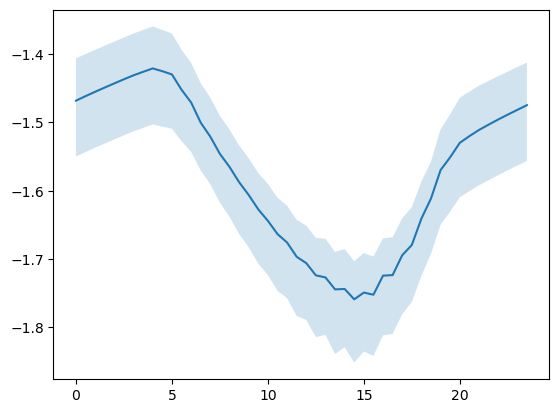

In [18]:
var = 'psiLeaf'
plt.plot(np.arange(0, 24, 0.5),dfm[var])
plt.fill_between(np.arange(0, 24, 0.5), dfql[var],dfqu[var], alpha=0.2)

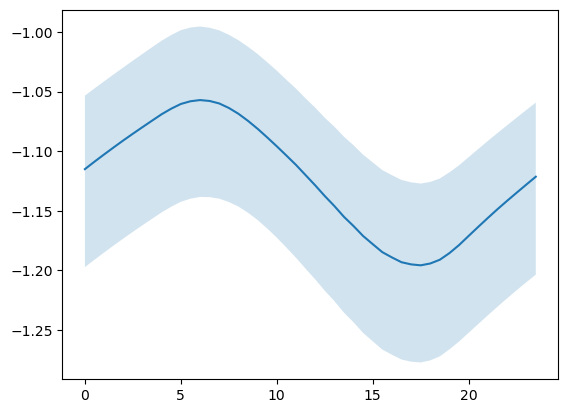

In [19]:
var = 'psiStem'
plt.plot(np.arange(0, 24, 0.5),dfm[var])
plt.fill_between(np.arange(0, 24, 0.5), dfql[var],dfqu[var], alpha=0.2)

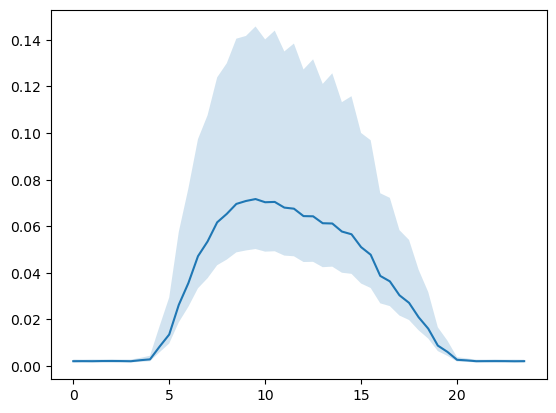

In [17]:
plt.plot(np.arange(0, 24, 0.5),dfm['gss'])
plt.fill_between(np.arange(0, 24, 0.5), dfql['gss'],dfqu['gss'], alpha=0.2)

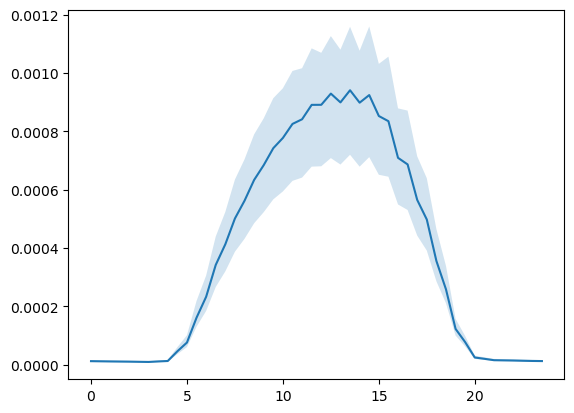

In [20]:
plt.plot(np.arange(0, 24, 0.5),dfm['T'])
plt.fill_between(np.arange(0, 24, 0.5), dfql['T'],dfqu['T'], alpha=0.2)

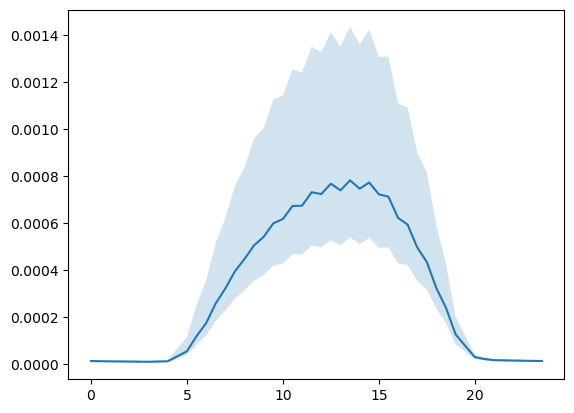

In [19]:
plt.plot(np.arange(0, 24, 0.5),dfm['J'])
plt.fill_between(np.arange(0, 24, 0.5), dfql['J'],dfqu['J'], alpha=0.2)

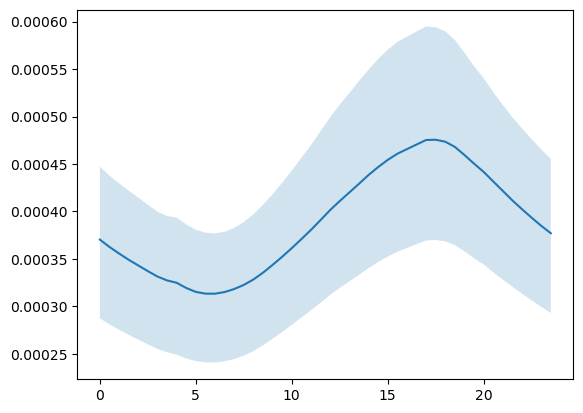

In [21]:
plt.plot(np.arange(0, 24, 0.5),dfm['G'])
plt.fill_between(np.arange(0, 24, 0.5), dfql['G'],dfqu['G'], alpha=0.2)

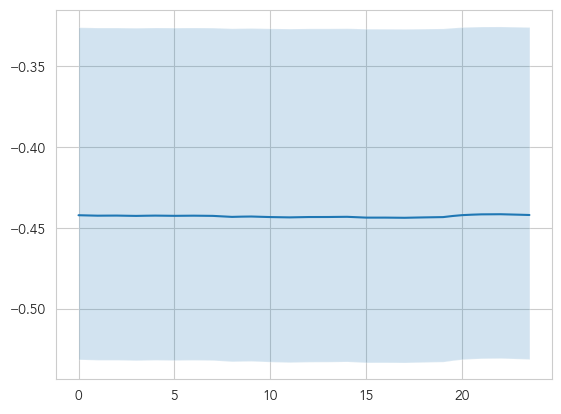

In [ ]:
plt.fill_between(np.arange(0, 24, 0.5), dfql['psiSoilUp'], dfqu['psiSoilUp'], alpha=0.2)
plt.plot(np.arange(0, 24, 0.5), dfm['psiSoilUp'])


In [22]:
for i in [2,4,5]:
    print(np.round(df_ax_ql[i]['rmse'].iloc[0],2))
    print(np.round(df_ax_m[i]['rmse'].iloc[0],2))
    print(np.round(df_ax_qu[i]['rmse'].iloc[0],2))
    print("")

0.68
0.69
0.69

1.56
1.59
1.61

0.97
0.98
0.99



(-7.0, 0.0)

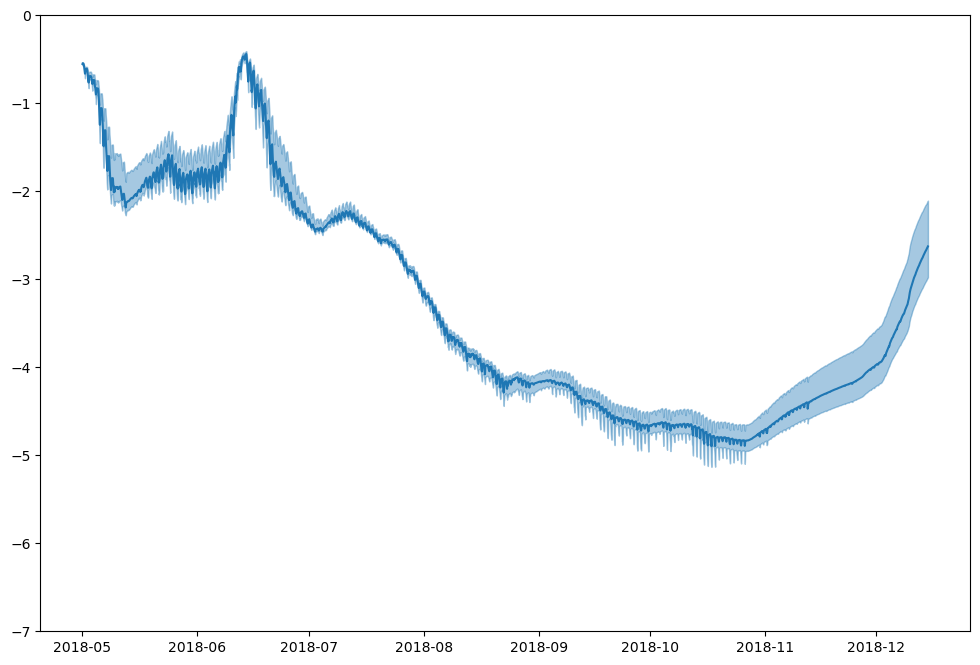

In [23]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(1,1, 1)
ax.plot(df_ax_m[2]['psiLeaf'], zorder =1, c = 'tab:blue')
ax.fill_between(df_ax_m[2].index, df_ax_ql[2]['psiLeaf'], df_ax_qu[2]['psiLeaf'], zorder =1, color = 'tab:blue' ,alpha=0.4)
ax.set_ylim(-7.0, 0)

In [ ]:
plt.rcParams["font.family"] = "Avenir"

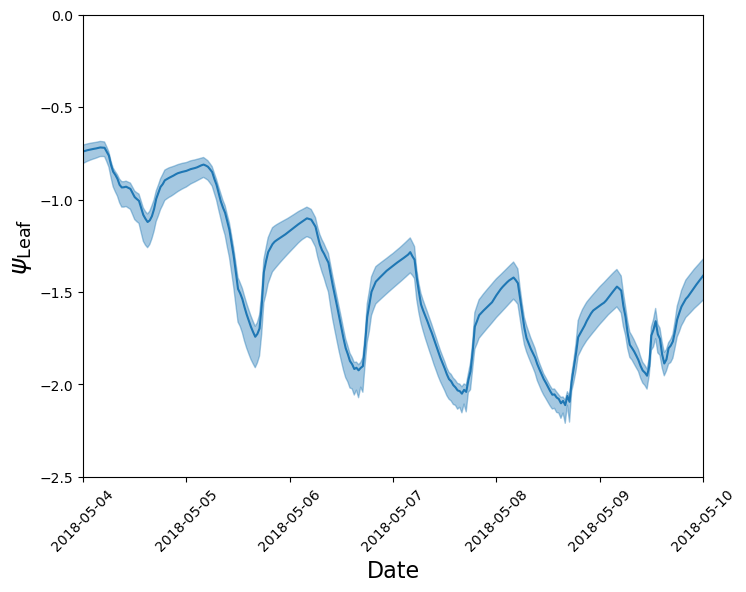

In [24]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:blue')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:blue' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-05-04'), pd.Timestamp('2018-05-10'))
ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize = 16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize = 18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P1.png"), bbox_inches='tight', dpi = 300)

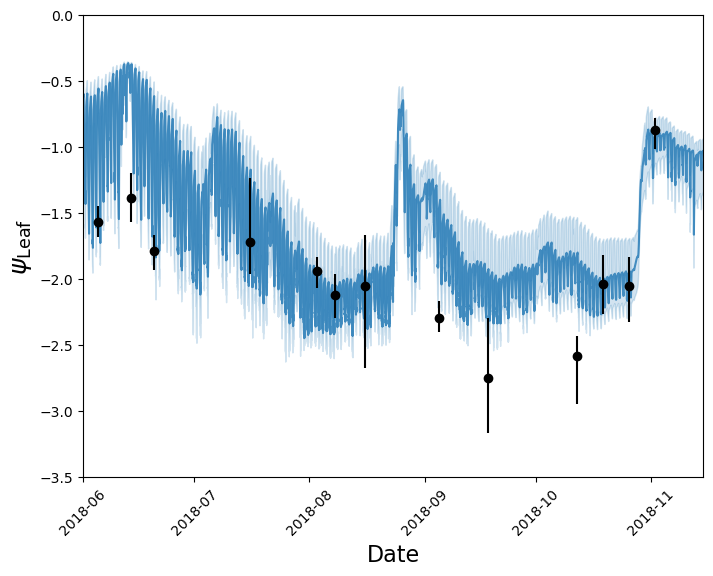

In [25]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:blue' ,alpha=0.8)
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:blue',
                alpha=0.2)
df_tree_mean = trees[ii].groupby(trees[ii].index).mean()
df_tree_lower = trees[ii].groupby(trees[ii].index).min()
df_tree_upper = trees[ii].groupby(trees[ii].index).max()
ax.errorbar(df_tree_mean.index, df_tree_mean['xylem_pressure'], yerr =[df_tree_mean['xylem_pressure']-df_tree_lower['xylem_pressure'],
                                                                       df_tree_upper['xylem_pressure'] - df_tree_mean['xylem_pressure']] ,color = 'black', fmt= 'o')
ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-11-15'))
plt.xticks(rotation=45)
ax.set_ylim(-3.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.savefig(os.path.join(post_path, "F1_P2.png"), bbox_inches='tight', dpi=300)

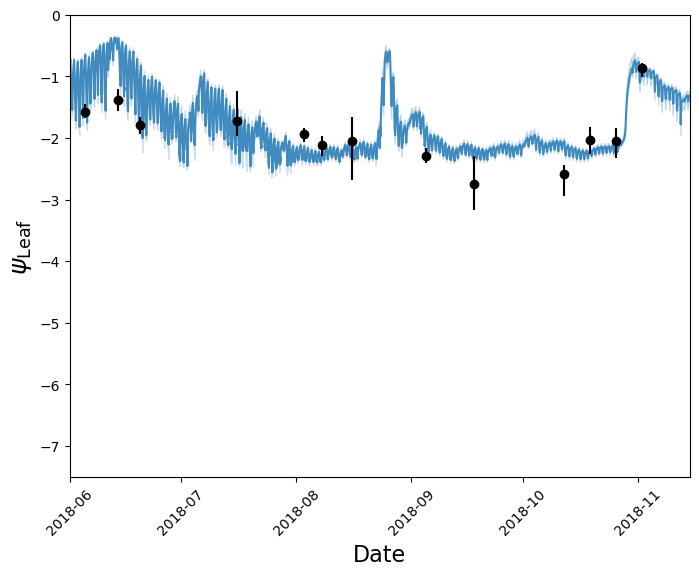

In [25]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:blue' ,alpha=0.8)
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:blue',
                alpha=0.2)
df_tree_mean = trees[ii].groupby(trees[ii].index).mean()
df_tree_lower = trees[ii].groupby(trees[ii].index).min()
df_tree_upper = trees[ii].groupby(trees[ii].index).max()
ax.errorbar(df_tree_mean.index, df_tree_mean['xylem_pressure'], yerr =[df_tree_mean['xylem_pressure']-df_tree_lower['xylem_pressure'],
                                                                       df_tree_upper['xylem_pressure'] - df_tree_mean['xylem_pressure']] ,color = 'black', fmt= 'o')
ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-11-15'))
ax.set_ylim(-7.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P3.png"), bbox_inches='tight', dpi=300)

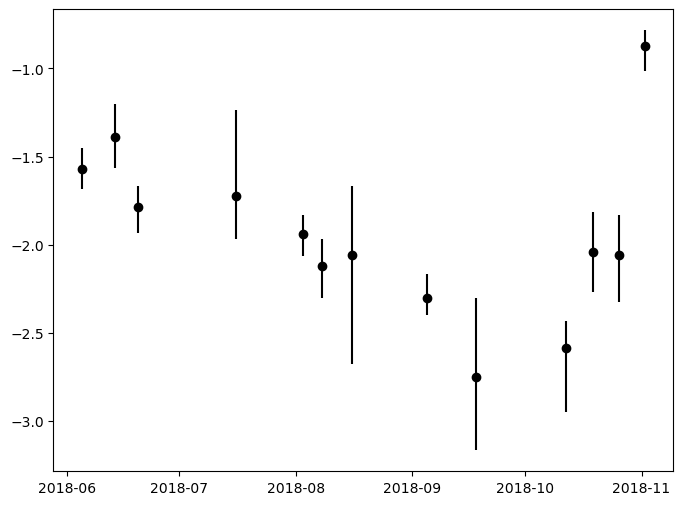

In [27]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
df_tree_mean = trees[ii].groupby(trees[ii].index).mean()
df_tree_lower = trees[ii].groupby(trees[ii].index).min()
df_tree_upper = trees[ii].groupby(trees[ii].index).max()
ax.errorbar(df_tree_mean.index, df_tree_mean['xylem_pressure'], yerr =[df_tree_mean['xylem_pressure']-df_tree_lower['xylem_pressure'],
                                                                       df_tree_upper['xylem_pressure'] - df_tree_mean['xylem_pressure']] ,color = 'black', fmt= 'o')
plt.show()

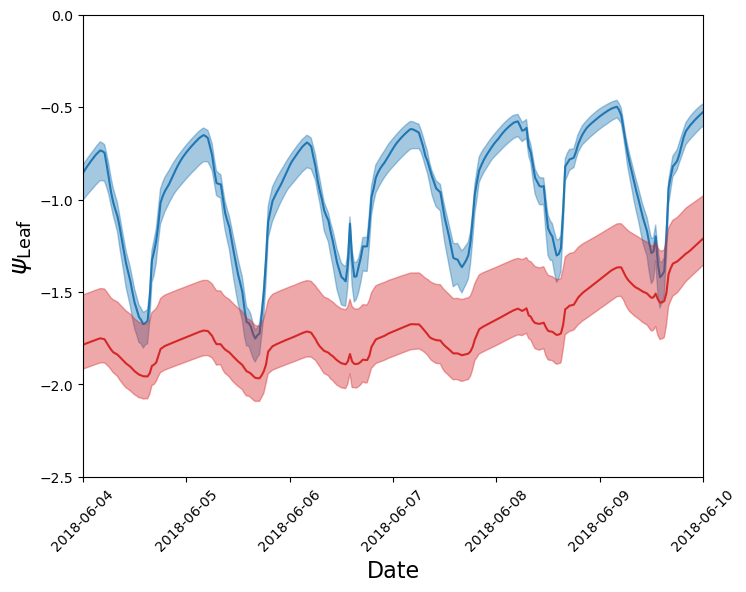

In [26]:

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:blue')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:blue' ,alpha=0.4)
ii = 2
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:red' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-06-04'), pd.Timestamp('2018-06-10'))
ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P4.png"), bbox_inches='tight', dpi=300)

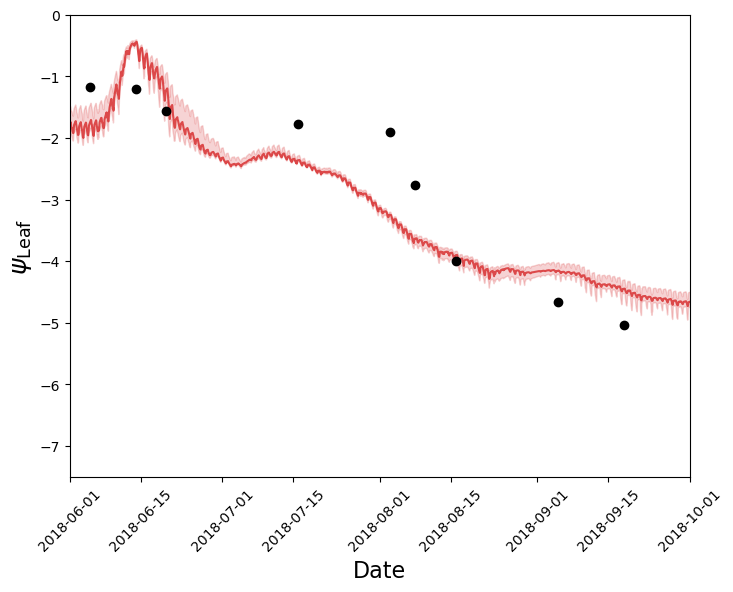

In [27]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 2
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red', alpha=0.8)
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.scatter(trees[ii].index, trees[ii]['xylem_pressure'], color= 'black', zorder =2)
ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-7.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P5.png"), bbox_inches='tight', dpi=300)

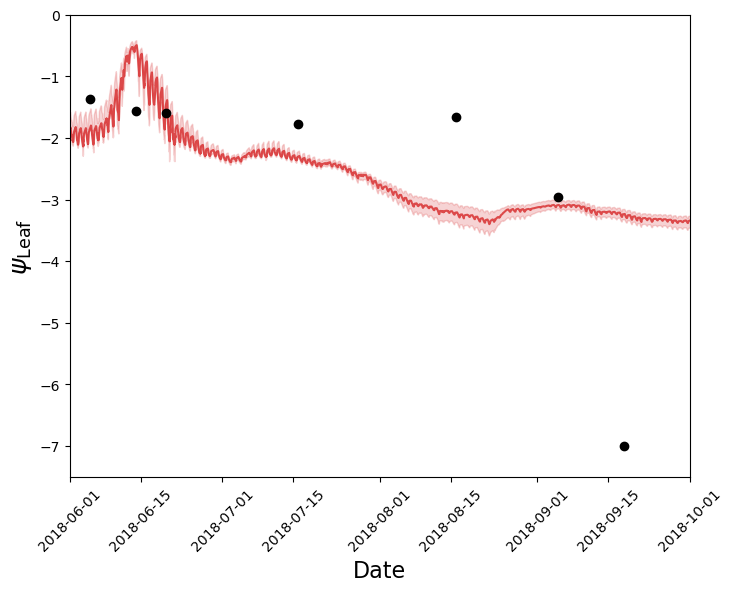

In [28]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 4
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red', alpha=0.8)
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.scatter(trees[ii].index, trees[ii]['xylem_pressure'], color= 'black', zorder =2)
ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-7.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P6.png"), bbox_inches='tight', dpi=300)

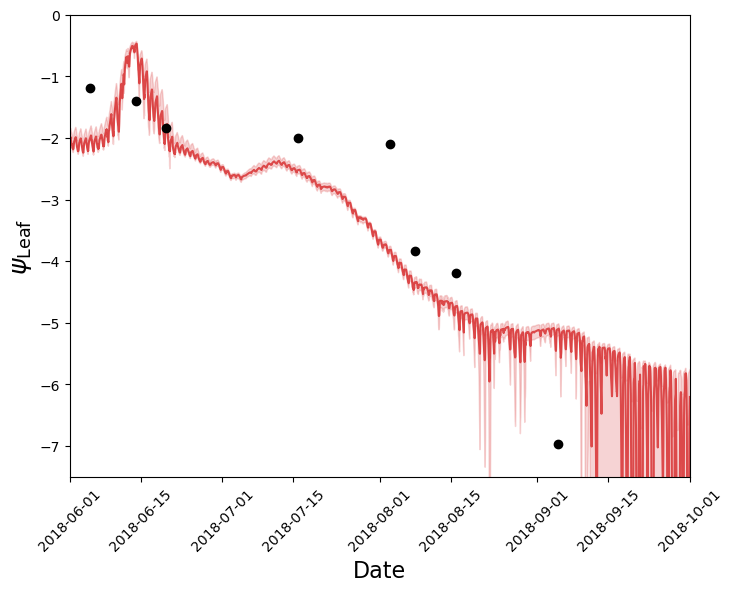

In [29]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 5
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red', alpha=0.8)
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.scatter(trees[ii].index, trees[ii]['xylem_pressure'], color= 'black', zorder =2)
ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-7.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P7.png"), bbox_inches='tight', dpi=300)

(-8.0, 0.0)

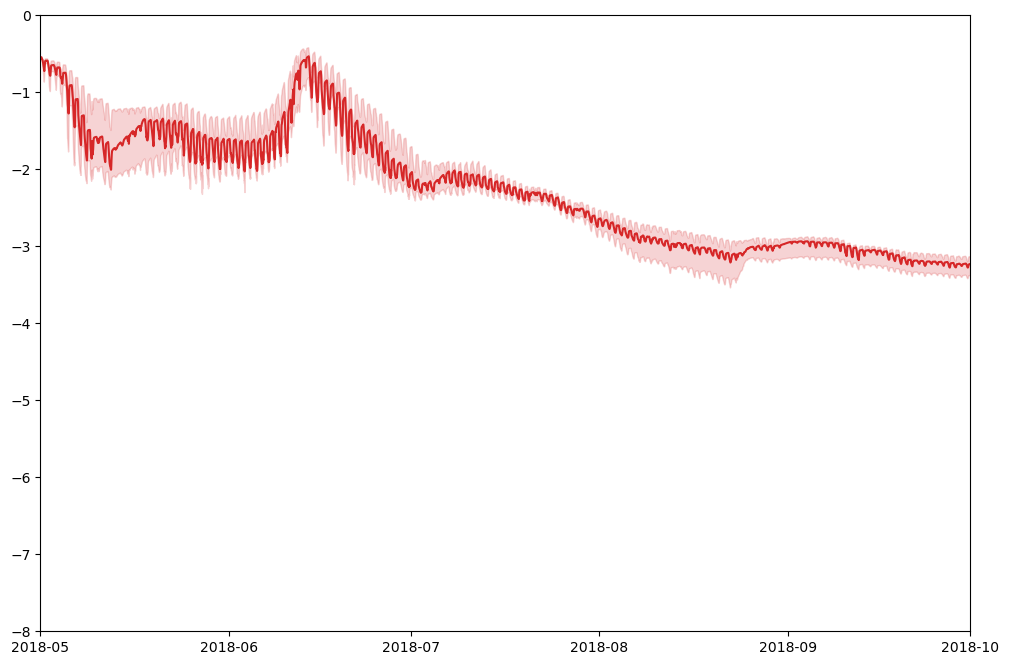

In [32]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(1,1, 1)
ii = 4
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:red' ,alpha=0.2)
ax.set_xlim(pd.Timestamp('2018-05-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-8, 0)

(-8.0, 0.0)

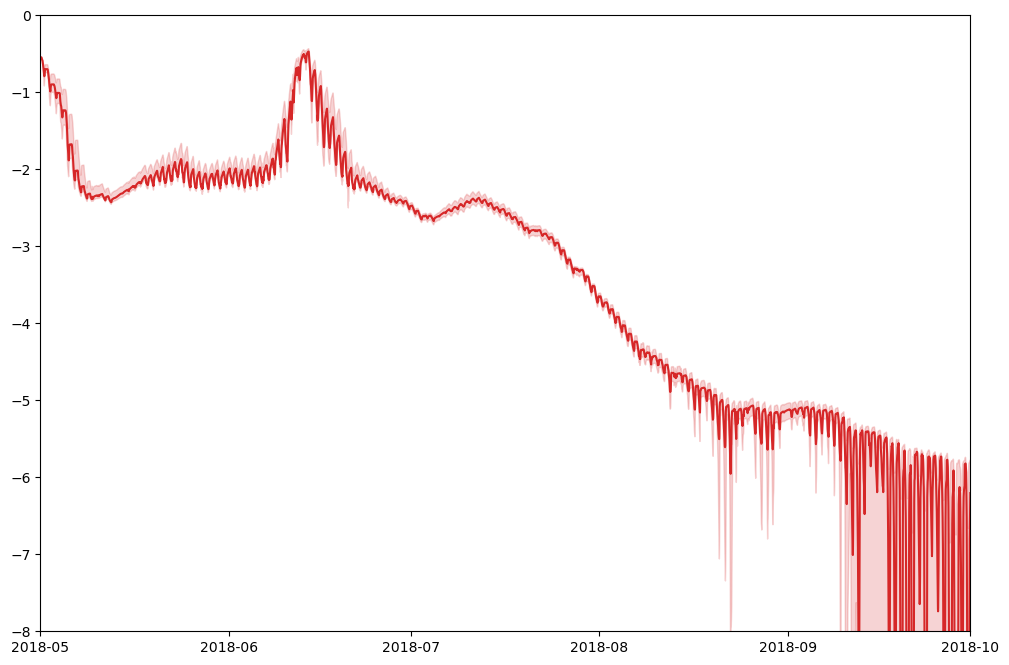

In [30]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(1,1, 1)
ii = 5
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:red' ,alpha=0.2)
ax.set_xlim(pd.Timestamp('2018-05-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-8, 0)

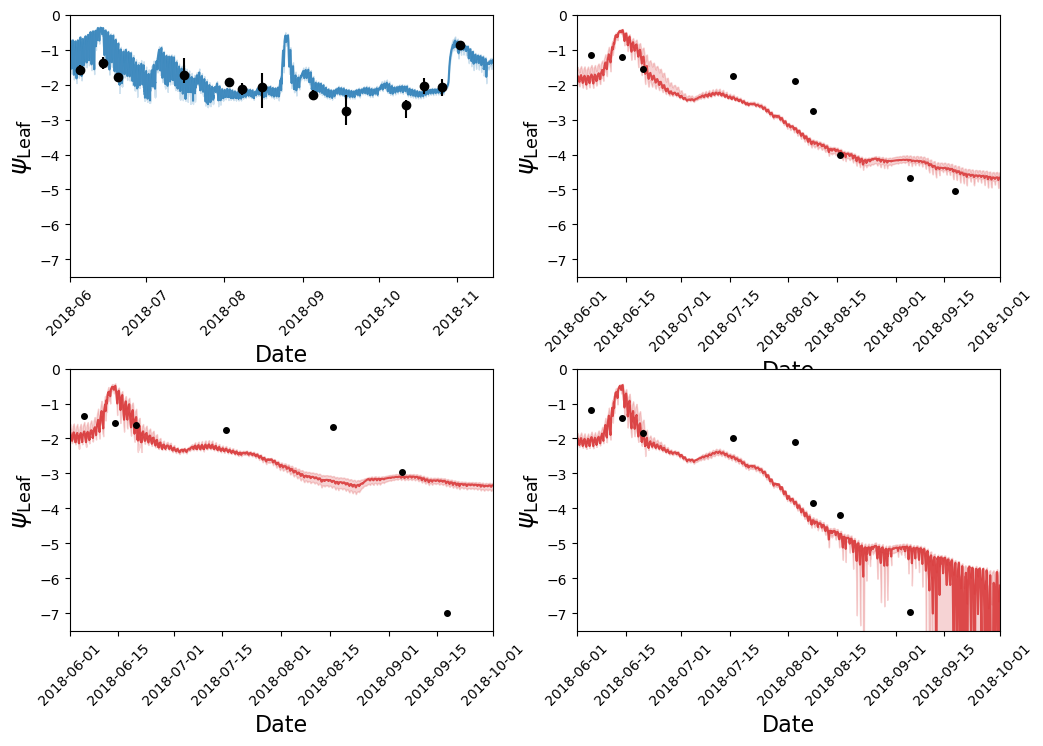

In [31]:
fig = plt.figure(figsize=(12, 8))


for i, ii in zip(range(1,5),[1,2,4,5]):
    if ii == 1:
        col = 'tab:blue'
    else:
        col = 'tab:red'
    ax = fig.add_subplot(2, 2, i)
    ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c=col, alpha=0.8)
    ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color=col,
                    alpha=0.2)
    if ii == 1:
        df_tree_mean = trees[ii].groupby(trees[ii].index).mean()
        df_tree_lower = trees[ii].groupby(trees[ii].index).min()
        df_tree_upper = trees[ii].groupby(trees[ii].index).max()
        ax.errorbar(df_tree_mean.index, df_tree_mean['xylem_pressure'], yerr =[df_tree_mean['xylem_pressure']-df_tree_lower['xylem_pressure'],
                                                        df_tree_upper['xylem_pressure'] - df_tree_mean['xylem_pressure']] ,color = 'black', fmt= 'o')
    
    else:
        ax.scatter(trees[ii].index, trees[ii]['xylem_pressure'], color= 'black', zorder =2, s =16)
    if ii == 1:
        ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-11-15'))
    else:
        ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-10-1'))
    ax.set_ylim(-7.5, 0)
    ax.set_xlabel("Date", fontsize=16)
    ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
    plt.xticks(rotation=45)
plt.subplots_adjust(hspace=0.35)
plt.savefig(os.path.join(post_path, "F1_ALL.png"), bbox_inches='tight', dpi=300)

(array([17655., 17656., 17657., 17658., 17659., 17660., 17661.]),
 [Text(17655.0, 0, '2018-05-04'),
  Text(17656.0, 0, '2018-05-05'),
  Text(17657.0, 0, '2018-05-06'),
  Text(17658.0, 0, '2018-05-07'),
  Text(17659.0, 0, '2018-05-08'),
  Text(17660.0, 0, '2018-05-09'),
  Text(17661.0, 0, '2018-05-10')])

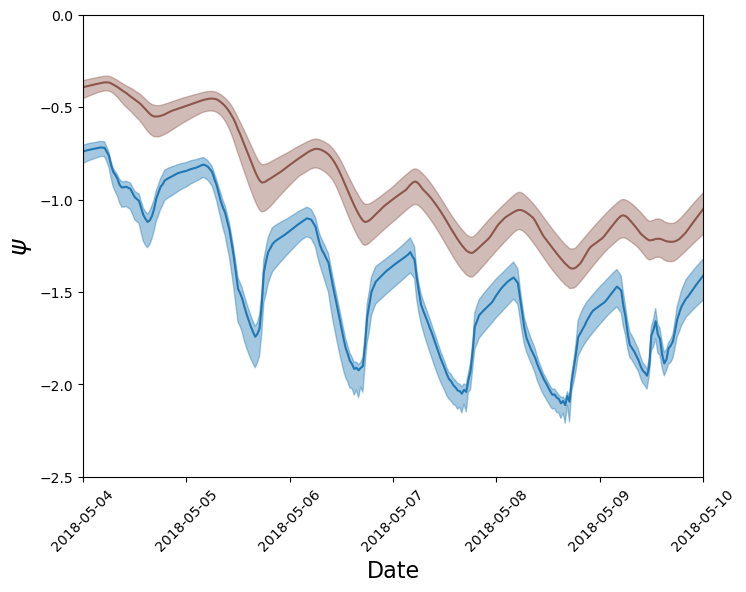

In [32]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:blue')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:blue' ,alpha=0.4)
ax.plot(df_ax_m[ii]['psiStem'], zorder =1, c = 'tab:brown')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiStem'], df_ax_qu[ii]['psiStem'], zorder =1, color = 'tab:brown' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-05-04'), pd.Timestamp('2018-05-10'))
ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize = 16)
ax.set_ylabel(r"$\psi$", fontsize = 18)
plt.xticks(rotation=45)
#plt.savefig(os.path.join(post_path, "F1_P1.png"), bbox_inches='tight', dpi = 300)

(-8.0, 0.0)

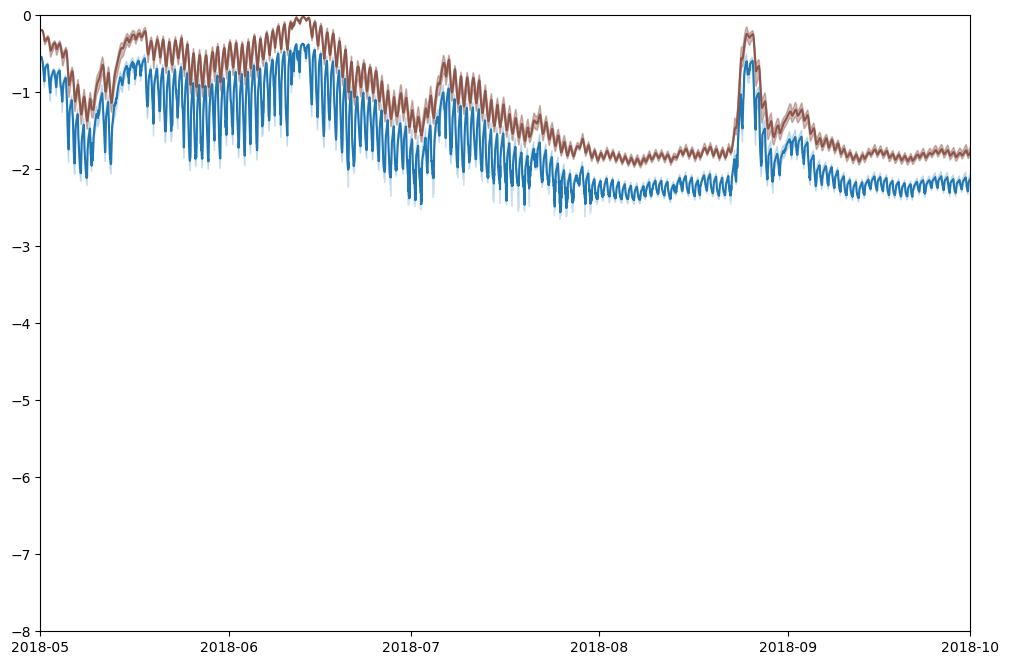

In [33]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:blue')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:blue',
                alpha=0.2)
ax.plot(df_ax_m[ii]['psiStem'], zorder =1, c = 'tab:brown')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiStem'], df_ax_qu[ii]['psiStem'], zorder =1, color = 'tab:brown' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-05-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-8, 0)

(-10.0, 0.0)

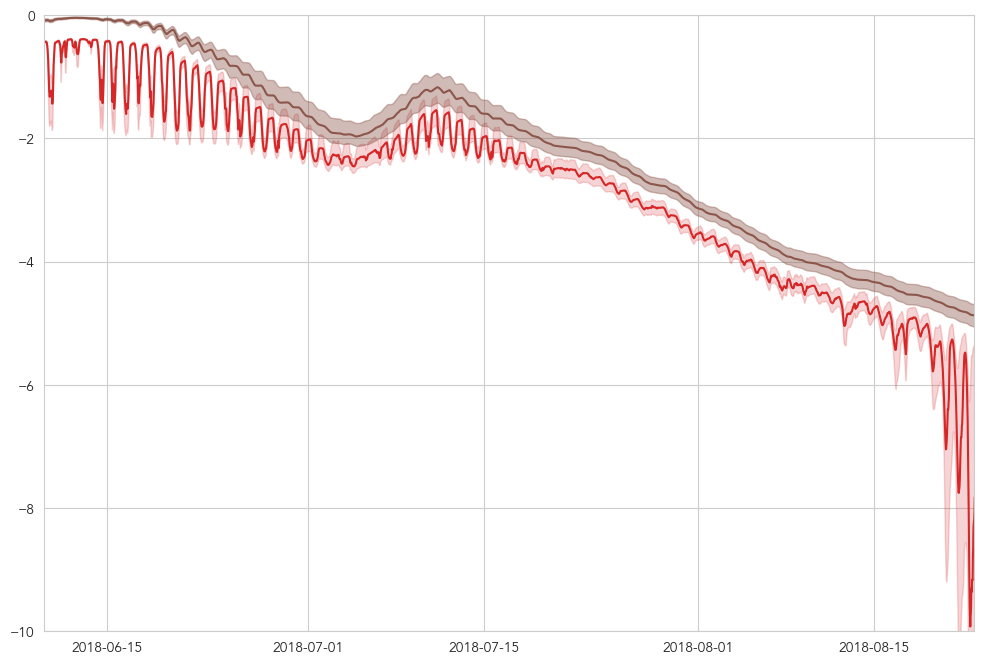

In [ ]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 5
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.plot(df_ax_m[ii]['psiStem'], zorder =1, c = 'tab:brown')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiStem'], df_ax_qu[ii]['psiStem'], zorder =1, color = 'tab:brown' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-06-10'), pd.Timestamp('2018-8-23'))
ax.set_ylim(-10, 0)

(-10.0, 0.0)

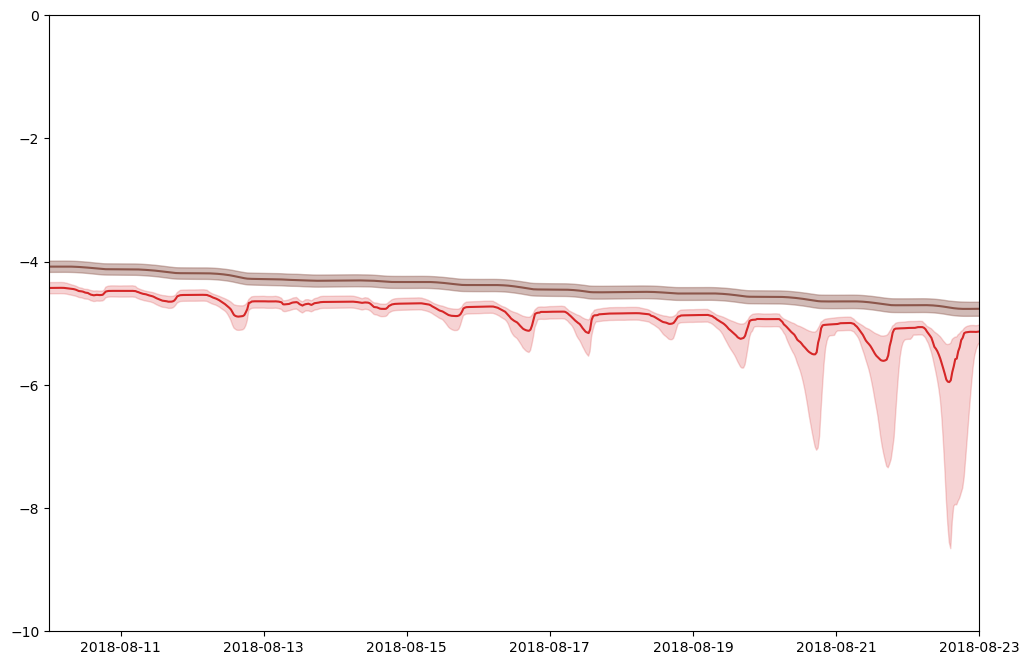

In [34]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 5
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.plot(df_ax_m[ii]['psiStem'], zorder =1, c = 'tab:brown')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiStem'], df_ax_qu[ii]['psiStem'], zorder =1, color = 'tab:brown' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-08-10'), pd.Timestamp('2018-8-23'))
ax.set_ylim(-10, 0)

(array([17720., 17727., 17734., 17744., 17751., 17758., 17765., 17775.,
        17782.]),
 [Text(17720.0, 0, '2018-07-08'),
  Text(17727.0, 0, '2018-07-15'),
  Text(17734.0, 0, '2018-07-22'),
  Text(17744.0, 0, '2018-08-01'),
  Text(17751.0, 0, '2018-08-08'),
  Text(17758.0, 0, '2018-08-15'),
  Text(17765.0, 0, '2018-08-22'),
  Text(17775.0, 0, '2018-09-01'),
  Text(17782.0, 0, '2018-09-08')])

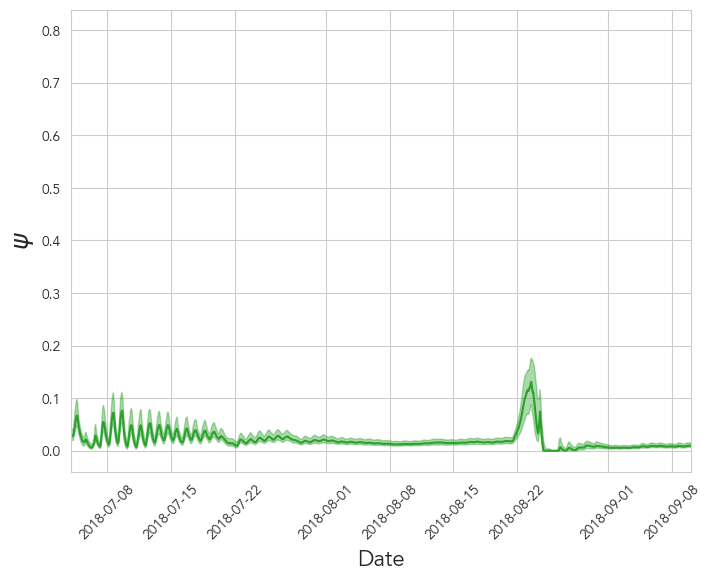

In [ ]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1, 1)
ii = 1
ax.plot(df_ax_m[ii]['Gs'], zorder =1, c = 'tab:green')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['Gs'], df_ax_qu[ii]['Gs'], zorder = 1, color = 'tab:green' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-07-04'), pd.Timestamp('2018-09-10'))
#ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize = 16)
ax.set_ylabel(r"$\psi$", fontsize = 18)
plt.xticks(rotation=45)

(array([17652., 17666., 17683., 17697., 17713., 17727., 17744., 17758.,
        17775.]),
 [Text(17652.0, 0, '2018-05-01'),
  Text(17666.0, 0, '2018-05-15'),
  Text(17683.0, 0, '2018-06-01'),
  Text(17697.0, 0, '2018-06-15'),
  Text(17713.0, 0, '2018-07-01'),
  Text(17727.0, 0, '2018-07-15'),
  Text(17744.0, 0, '2018-08-01'),
  Text(17758.0, 0, '2018-08-15'),
  Text(17775.0, 0, '2018-09-01')])

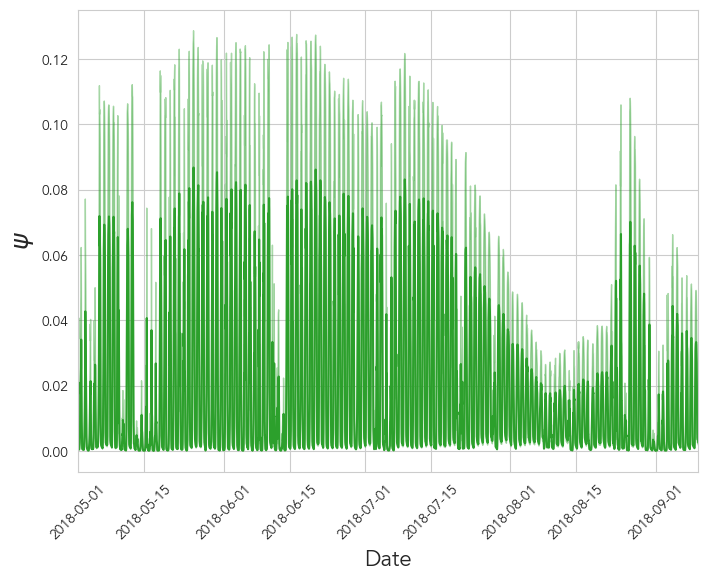

In [ ]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1, 1)
ii = 1
ax.plot(df_ax_m[ii]['Js'], zorder =1, c = 'tab:green')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['Js'], df_ax_qu[ii]['Js'], zorder = 1, color = 'tab:green' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-05-01'), pd.Timestamp('2018-09-10'))
#ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize = 16)
ax.set_ylabel(r"$\psi$", fontsize = 18)
plt.xticks(rotation=45)

(array([17666., 17668., 17670., 17672., 17674., 17676., 17678., 17680.,
        17682., 17683.]),
 [Text(17666.0, 0, '2018-05-15'),
  Text(17668.0, 0, '2018-05-17'),
  Text(17670.0, 0, '2018-05-19'),
  Text(17672.0, 0, '2018-05-21'),
  Text(17674.0, 0, '2018-05-23'),
  Text(17676.0, 0, '2018-05-25'),
  Text(17678.0, 0, '2018-05-27'),
  Text(17680.0, 0, '2018-05-29'),
  Text(17682.0, 0, '2018-05-31'),
  Text(17683.0, 0, '2018-06-01')])

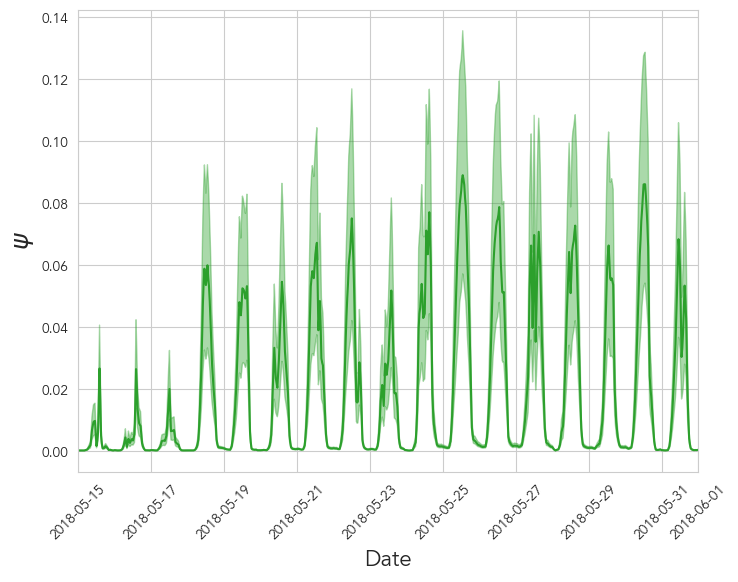

In [ ]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1, 1)
ii = 2
ax.plot(df_ax_m[ii]['Js'], zorder =1, c = 'tab:green')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['Js'], df_ax_qu[ii]['Js'], zorder = 1, color = 'tab:green' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-05-15'), pd.Timestamp('2018-06-1'))
#ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize = 16)
ax.set_ylabel(r"$\psi$", fontsize = 18)
plt.xticks(rotation=45)

In [ ]:
0.06 * 100/1000*18*1000

108.0

(-10.0, 0.0)

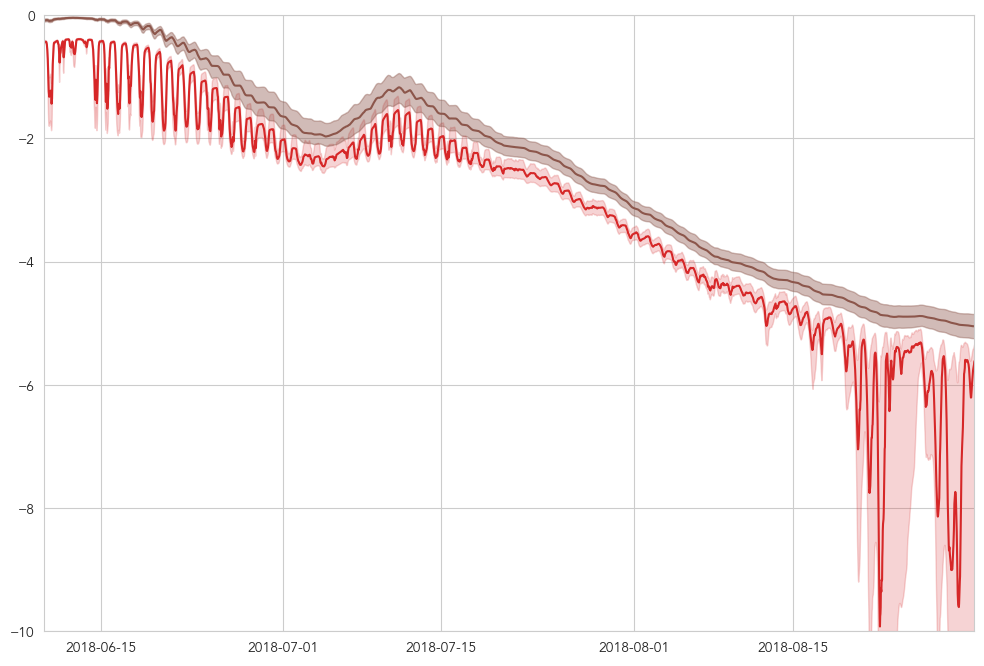

In [ ]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 5
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.plot(df_ax_m[ii]['psiStem'], zorder =1, c = 'tab:brown')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiStem'], df_ax_qu[ii]['psiStem'], zorder =1, color = 'tab:brown' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-06-10'), pd.Timestamp('2018-8-31'))
ax.set_ylim(-10, 0)

(17727.0, 17774.0)

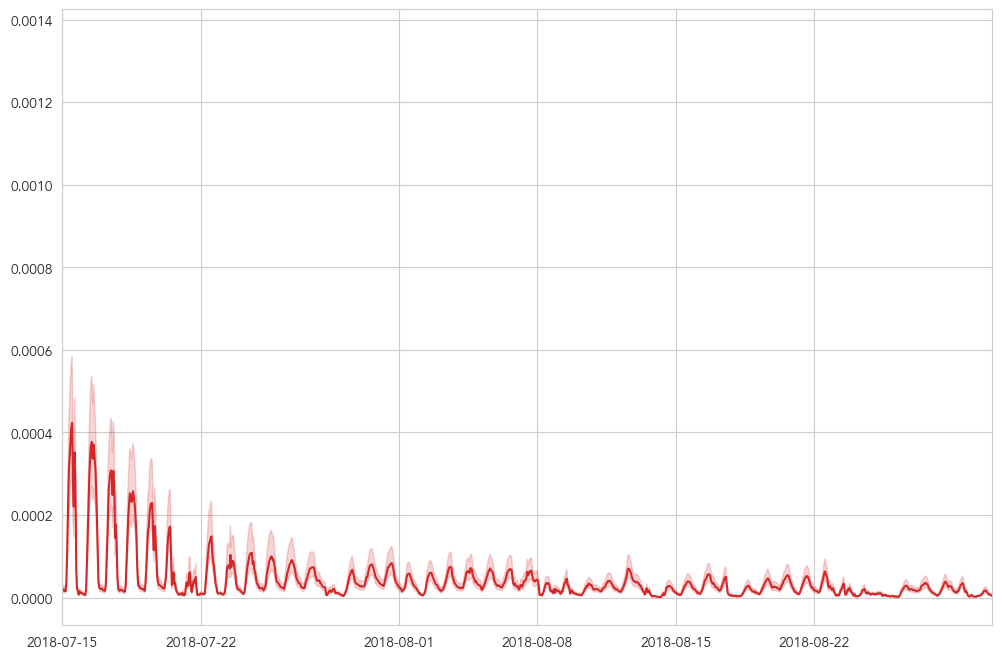

In [ ]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 2
ax.plot(df_ax_m[ii]['T'], zorder=1, c='tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['T'], df_ax_qu[ii]['T'], zorder=1, color='tab:red',
                alpha=0.2)
ax.set_xlim(pd.Timestamp('2018-07-15'), pd.Timestamp('2018-8-31'))

(17727.0, 17774.0)

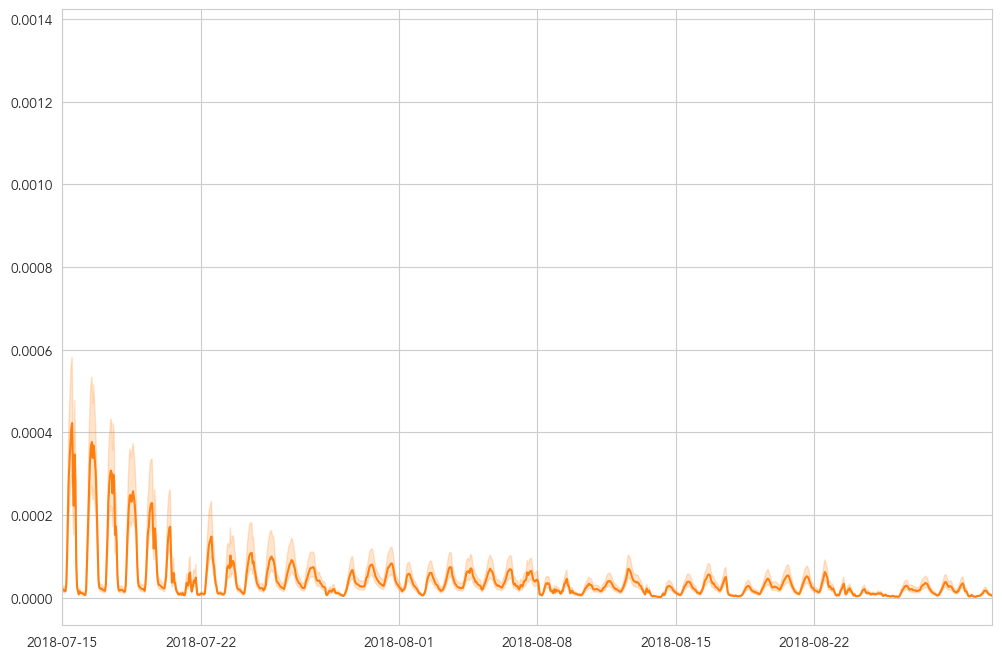

In [ ]:
ax.set_ylim(-10, 0)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 2
ax.plot(df_ax_m[ii]['J'], zorder=1, c='tab:orange')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['J'], df_ax_qu[ii]['J'], zorder=1, color='tab:orange',
                alpha=0.2)
ax.set_xlim(pd.Timestamp('2018-07-15'), pd.Timestamp('2018-8-31'))

(17727.0, 17774.0)

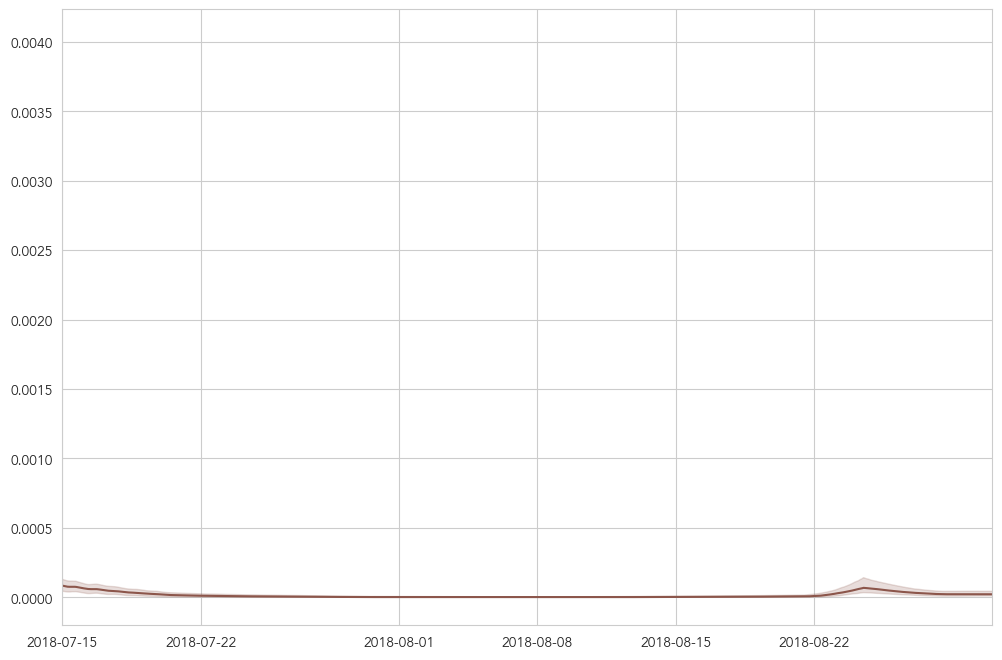

In [ ]:
ax.set_ylim(-10, 0)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 2
ax.plot(df_ax_m[ii]['G'], zorder=1, c='tab:brown')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['G'], df_ax_qu[ii]['G'], zorder=1, color='tab:brown',
                alpha=0.2)
ax.set_xlim(pd.Timestamp('2018-07-15'), pd.Timestamp('2018-8-31'))

In [ ]:
df_ax_m[ii]['T'].mean()

7.204494153350238e-05

In [ ]:
df_ax_m[ii]['T']['2018-07-15':'2018-08-15'].mean()

5.199918513894749e-05

In [ ]:
ii=2
df_ax_m[ii]['vpd']['2018-08-1':'2018-09-01'].mean()

1000.6303757727146

In [ ]:
ii = 2
df_ax_m[ii]['gss']['2018-08-01':'2018-09-01'].mean()

0.0023696906864643097

In [ ]:
ii = 2
df_ax_m[ii]['T']['2018-08-01':'2018-09-01'].mean()

2.3407545689302367e-05

In [ ]:
ii = 2
df_ax_m[ii]['gss']['2018-08-01':'2018-09-01'].mean()

0.0023696906864643097

In [ ]:
ii = 2
df_ax_m[ii]['psiLeaf']['2018-08-01'].min()-df_ax_m[ii]['psiLeaf']['2018-09-01'].min()

1.2117869853973389

In [ ]:
1.2486491203308105 / 31

0.04027900388163905

In [ ]:
ii = 5
df_ax_m[ii]['psiLeaf']['2018-08-01'].min() - df_ax_m[ii]['psiLeaf']['2018-08-15'].min()

1.455795168876648

In [ ]:
1.455795168876648/15

0.09705301125844319

In [ ]:
ii=2
df_ax_m[ii]['vpd']['2018-08-1':'2018-08-15'].mean()

1280.0490270879534